In [15]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

# Set visualization style and parameters
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

FILE_NAME = "warspotting_losses.xlsx"
df = pd.read_excel(FILE_NAME)

print(f"Dataset loaded. Total rows: {len(df)}")
print("\nInitial DataFrame Information")
df.info()

Dataset loaded. Total rows: 20055

Initial DataFrame Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20055 entries, 0 to 20054
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                20055 non-null  int64  
 1   date              20055 non-null  object 
 2   type              20055 non-null  object 
 3   model             20055 non-null  object 
 4   status            20055 non-null  object 
 5   lost_by           20055 non-null  object 
 6   nearest_location  18784 non-null  object 
 7   geo               11895 non-null  object 
 8   unit              3971 non-null   object 
 9   tags              12853 non-null  object 
 10  comment           0 non-null      float64
 11  sources           0 non-null      float64
 12  photos            0 non-null      float64
dtypes: float64(3), int64(1), object(9)
memory usage: 2.0+ MB


In [16]:
# Data Inspection
print("First 5 Rows:")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

print("\nDescription:")
print(df.describe(include=['int64', 'float64']).to_markdown())

print("\nValue Counts:")
print("Status Counts:")
print(df['status'].value_counts().head().to_markdown())
print("\nType Counts:")
print(df['type'].value_counts().head().to_markdown())

First 5 Rows:
| id   | date       | type                       | model                   | status    | lost_by   | nearest_location                    | geo                   | unit                                     | tags                         | comment   | sources   | photos   |
|:-----|:-----------|:---------------------------|:------------------------|:----------|:----------|:------------------------------------|:----------------------|:-----------------------------------------|:-----------------------------|:----------|:----------|:---------|
| 602  | 2022-02-24 | Tanks                      | T-80BVM                 | Destroyed | Russia    | Kharkiv, Kharkiv raion              | 50.0549042,36.3615697 | 200th Separate Motor Rifle Brigade       | Turretless, Mine plow/roller | nan       | nan       | nan      |
| 954  | 2022-02-24 | Infantry fighting vehicles | MT-LBVM(K)              | Destroyed | Russia    | Kharkiv, Kharkiv raion              | 50.054933,36.360974   | 25th Se

In [17]:
# Data Curating
df_clean = df.copy()
# We are not going to use the comment, sources, photos or empty columns(errors='ignore')
df_clean = df_clean.drop(columns=['comment', 'sources', 'photos'], errors='ignore')
# Remove rows where geographical data is missing
df_clean = df_clean.dropna(subset=['geo']).copy()
# Convert 'date't o datetime objects
df_clean['date'] = pd.to_datetime(df_clean['date'])
print(f"Total curated rows: {len(df_clean)}")

Total curated rows: 11895


In [18]:
# New Data Features
# Split geo into latitude and longitude as a string
df_clean[['latitude', 'longitude']] = df_clean['geo'].astype(str).str.split(',', expand=True)

df_clean['latitude'] = pd.to_numeric(df_clean['latitude'], errors='coerce')
df_clean['longitude'] = pd.to_numeric(df_clean['longitude'], errors='coerce')

df_clean = df_clean.dropna(subset=['latitude', 'longitude']).copy()

# Create a column for every count
df_clean['loss_count'] = 1 

# Create a column to show how many days the loss of the vehicle happened
START_DATE = date(2022, 2, 24)
df_clean['days_since_start'] = (df_clean['date'].dt.date - START_DATE).apply(lambda x: x.days).astype(int)

print("New Features:")
print(df_clean[['latitude', 'longitude', 'days_since_start', 'loss_count']].describe().to_markdown())

New Features:
|       |    latitude |   longitude |   days_since_start |   loss_count |
|:------|------------:|------------:|-------------------:|-------------:|
| count | 11895       | 11895       |          11895     |        11895 |
| mean  |    48.8268  |    36.2743  |            528.495 |            1 |
| std   |     1.37554 |     3.13359 |            377.321 |            0 |
| min   |    44.3888  |    28.3747  |              0     |            1 |
| 25%   |    47.8783  |    35.3512  |            123     |            1 |
| 50%   |    48.5776  |    37.3461  |            580     |            1 |
| 75%   |    49.6524  |    37.8429  |            848     |            1 |
| max   |    68.1468  |   103.583   |           1200     |            1 |


In [19]:
# Data Transformation
# Categorize equipment type into major operational roles
def categorize_type(equipment_type):
    if equipment_type in ['Tanks', 'Armoured Fighting Vehicle', 'Infantry fighting vehicles', 'Armoured Personnel Carrier']:
        return 'Armored Vehicles'
    elif equipment_type in ['Trucks', 'Fuel Truck', 'Utility Vehicle', 'Engineering Vehicle']:
        return 'Logistics/Support'
    elif equipment_type in ['Aircraft', 'Helicopters', 'Drones']:
        return 'Aviation'
    elif equipment_type in ['Artillery', 'Multiple Rocket Launchers', 'Self-Propelled Artillery', 'Mortars', 'Anti-aircraft systems']:
        return 'Indirect Fire/AA'
    else:
        return 'Other/Naval/EW'

# Create the new column
df_clean['loss_category'] = df_clean['type'].apply(categorize_type)

print("Categorized Column")
print(df_clean['loss_category'].value_counts().to_markdown())

Categorized Column
| loss_category    |   count |
|:-----------------|--------:|
| Armored Vehicles |    7592 |
| Other/Naval/EW   |    3922 |
| Indirect Fire/AA |     260 |
| Aviation         |     121 |


In [20]:
# Correlation matrix
corr_matrix = df_clean[['latitude', 'longitude', 'days_since_start', 'loss_count']].corr()

print("Correlation Matrix of Key Numeric Features")
print(corr_matrix.to_markdown())

Correlation Matrix of Key Numeric Features
|                  |   latitude |   longitude |   days_since_start |   loss_count |
|:-----------------|-----------:|------------:|-------------------:|-------------:|
| latitude         |   1        |   -0.17569  |          -0.146155 |          nan |
| longitude        |  -0.17569  |    1        |           0.388187 |          nan |
| days_since_start |  -0.146155 |    0.388187 |           1        |          nan |
| loss_count       | nan        |  nan        |         nan        |          nan |


In [48]:
# Gen classification function
def classify_full_generation(model):
    model_lower = str(model).lower()
    
    # Generation 1 (Old/Soviet Era, 1950s-70s)
    if any(m in model_lower for m in ['t-62', 't-55', 't-54', 'bmp-1', 'mt-lb', 'btr-60', 'btr-70', 'm-113', 'm113']):
        return '1_Old_Gen (1950s-70s)'
    
    # Generation 2 (Mid/Cold War Modern, 1980s-90s)
    elif any(m in model_lower for m in ['t-72', 't-80', 'bmp-2', 'btr-80', 'strv', 'm-60']):
        return '2_Mid_Gen (1980s-90s)'
    
    # Generation 3 (Modern/Post-Cold War, 2000s+)
    elif any(m in model_lower for m in ['t-90', 'bmp-3', 'btr-82', 'bradley', 'marder', 'cv90', 'leopard', 'challenger', 'abrams', 'stryker']):
        return '3_Modern_Gen (2000s+)'
    
    else:
        return '4_Other/Unknown'

df_clean['Model_Generation'] = df_clean['model'].apply(classify_full_generation)
print(df_clean[['model', 'type', 'Model_Generation']].head()) 
print(df_clean['Model_Generation'].value_counts(dropna=False))        

                     model                        type       Model_Generation
0                  T-80BVM                       Tanks  2_Mid_Gen (1980s-90s)
1               MT-LBVM(K)  Infantry fighting vehicles  1_Old_Gen (1950s-70s)
2  MT-LB with ZU-23 AA gun       Anti-aircraft systems  1_Old_Gen (1950s-70s)
3                 BMP-2(K)  Infantry fighting vehicles  2_Mid_Gen (1980s-90s)
5  KamAZ-63968 'Typhoon-K'  Infantry mobility vehicles        4_Other/Unknown
Model_Generation
4_Other/Unknown          5287
2_Mid_Gen (1980s-90s)    3190
1_Old_Gen (1950s-70s)    2089
3_Modern_Gen (2000s+)    1329
Name: count, dtype: int64


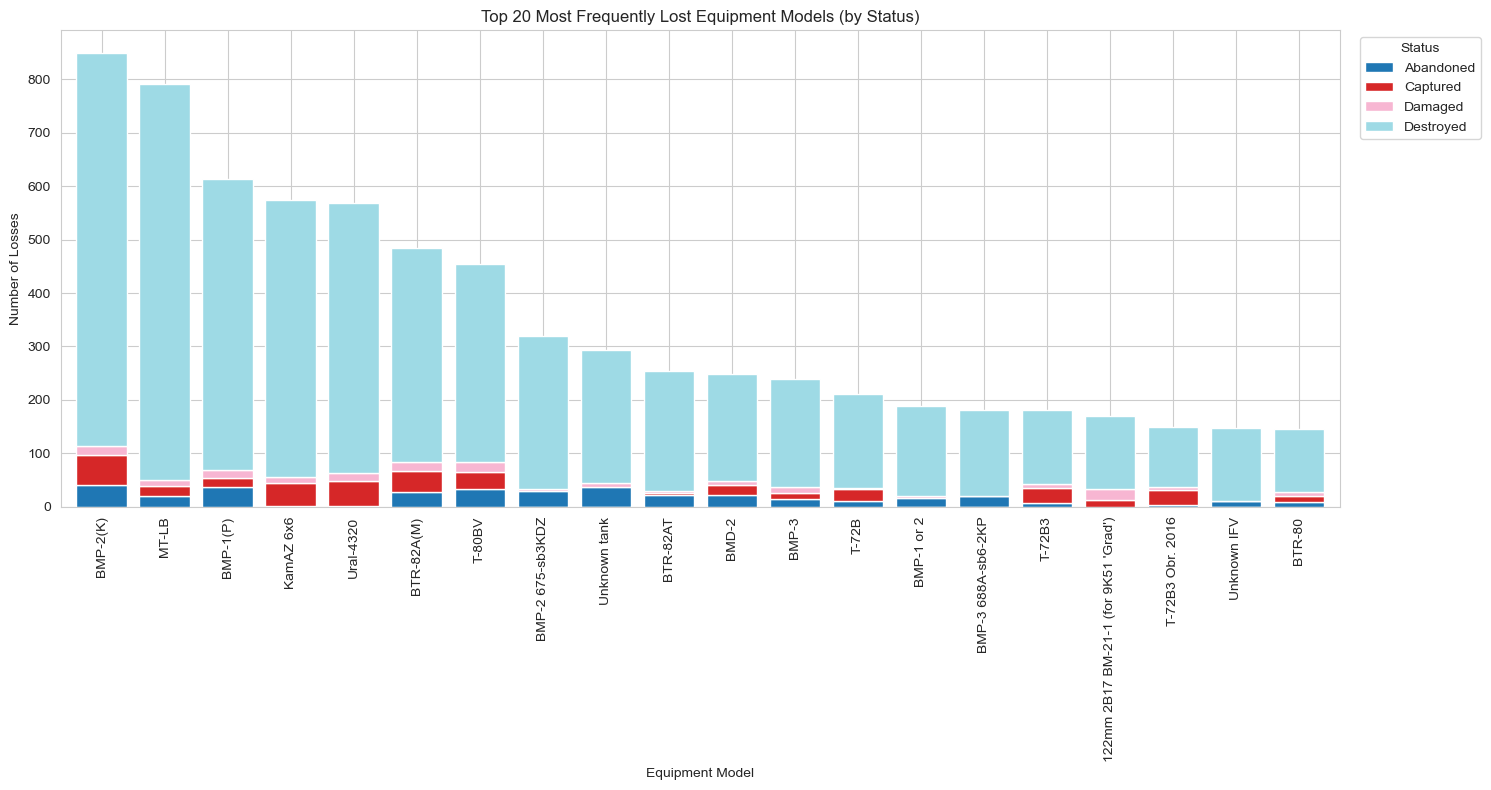

In [22]:
# Get top 20
top_20_models = df_clean['model'].value_counts().head(20).index
# Filter
df_top20 = df_clean[df_clean['model'].isin(top_20_models)]
# rows in order
status_by_model = pd.crosstab(df_top20['model'], df_top20['status'])
status_by_model = status_by_model.loc[top_20_models] #Reorder
# Plot stacked bar chart
bar = status_by_model.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 8),
    colormap='tab20',      # good for many categories
    width=0.8
)
plt.title('Top 20 Most Frequently Lost Equipment Models (by Status)'), 
plt.xlabel('Equipment Model')
plt.ylabel('Number of Losses')
plt.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

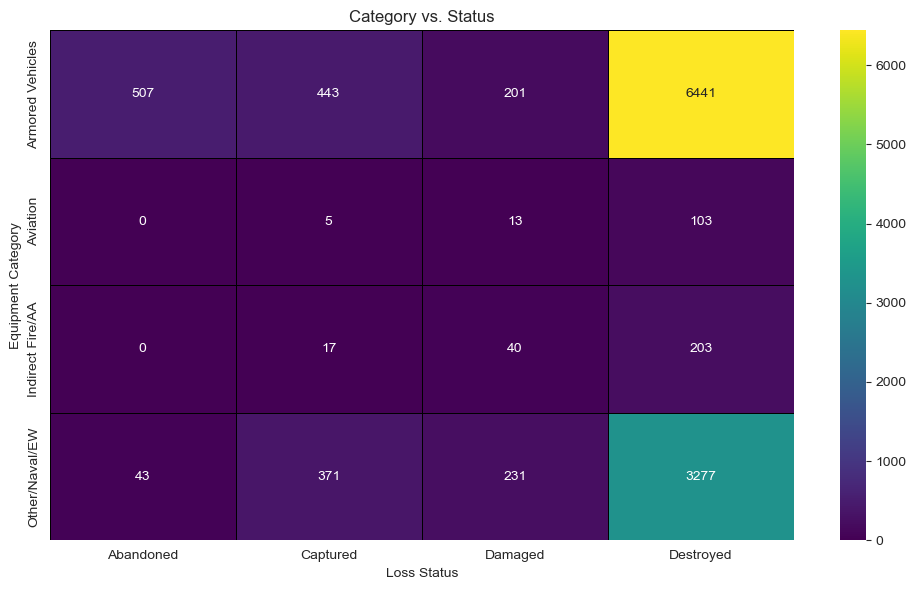

In [23]:
heatmap_data = df_clean.groupby(['loss_category', 'status'])['loss_count'].sum().unstack(fill_value=0)
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='d', # Format as integer
    cmap='viridis', # Color map
    linewidths=.5, 
    linecolor='black'
)
plt.title('Category vs. Status')
plt.ylabel('Equipment Category')
plt.xlabel('Loss Status')
plt.tight_layout()
plt.show()

C:\Users\clari\AppData\Local\Temp\ipykernel_10188\4110228408.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


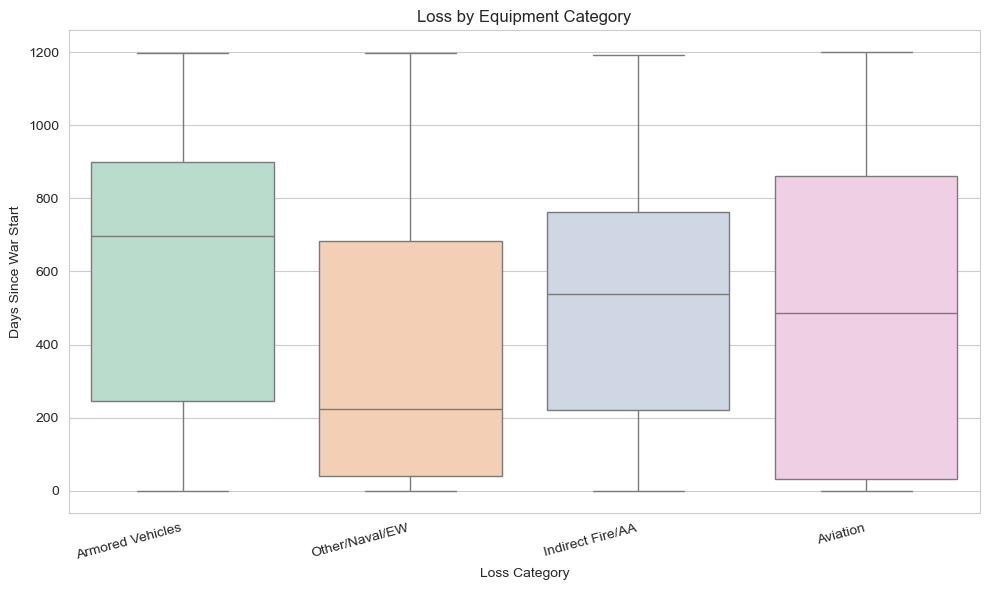

In [47]:
sns.boxplot(
    x='loss_category', 
    y='days_since_start', 
    data=df_clean,  
    palette="Pastel2",
    order=df_clean['loss_category'].value_counts().index.tolist()
)

plt.title('Loss by Equipment Category')
plt.xlabel('Loss Category')
plt.ylabel('Days Since War Start')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

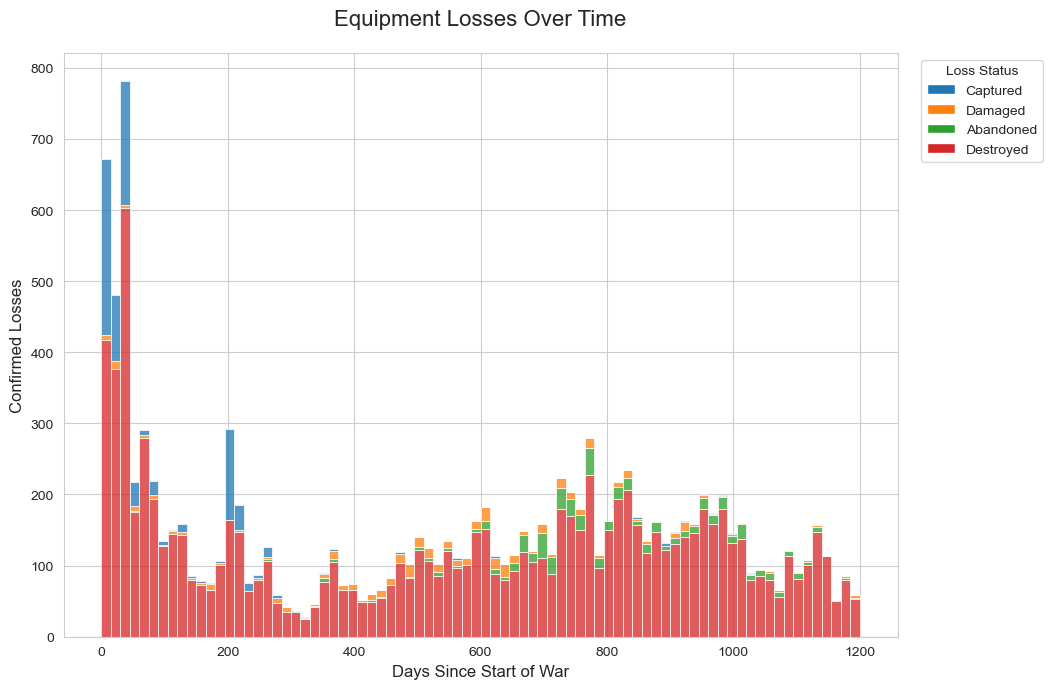

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter
major_statuses = ['Destroyed', 'Captured', 'Damaged', 'Abandoned']
df_plot = df_clean[df_clean['status'].isin(major_statuses)].copy()

status_order = ['Captured', 'Damaged', 'Abandoned', 'Destroyed']   # bottom → top
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']        # blue, orange, green, red

plt.figure(figsize=(13, 7))

ax = sns.histplot(
    data=df_plot,
    x='days_since_start',
    hue='status',
    hue_order=status_order,
    palette=colors,
    bins=80,
    multiple='stack',
    edgecolor='white',
    linewidth=0.5,
    legend=False
)

# Titles
plt.title('Equipment Losses Over Time', fontsize=16, pad=20)
plt.xlabel('Days Since Start of War', fontsize=12)
plt.ylabel('Confirmed Losses', fontsize=12)

# Legend
legend_labels = ['Captured', 'Damaged', 'Abandoned', 'Destroyed']
legend_patches = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white', label=l)
                  for c, l in zip(colors, legend_labels)]

ax.legend(handles=legend_patches,
          title='Loss Status',
          bbox_to_anchor=(1.02, 1),
          loc='upper left',
          frameon=True,
          fancybox=True)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

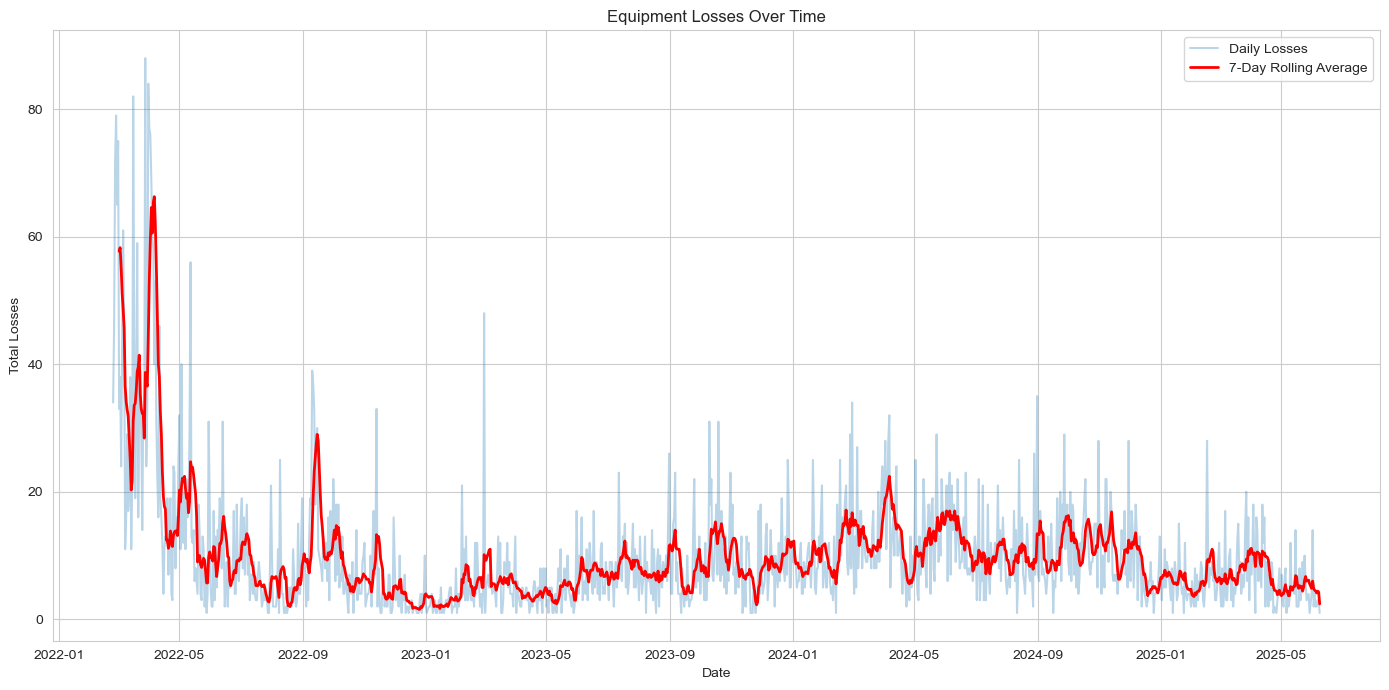

In [32]:
# Losses over time Line plot
# Aggregate losses by date
daily_losses = df_clean.groupby(df_clean['date'].dt.date)['loss_count'].sum()

# Apply a 7-day rolling average to smooth plot
rolling_avg = daily_losses.rolling(window=7).mean()

plt.figure(figsize=(14, 7))
daily_losses.plot(kind='line', alpha=0.3, label='Daily Losses')
rolling_avg.plot(kind='line', color='red', linewidth=2, label='7-Day Rolling Average')
plt.title('Equipment Losses Over Time')
plt.xlabel('Date')
plt.ylabel('Total Losses')
plt.legend()
plt.tight_layout()
plt.show()

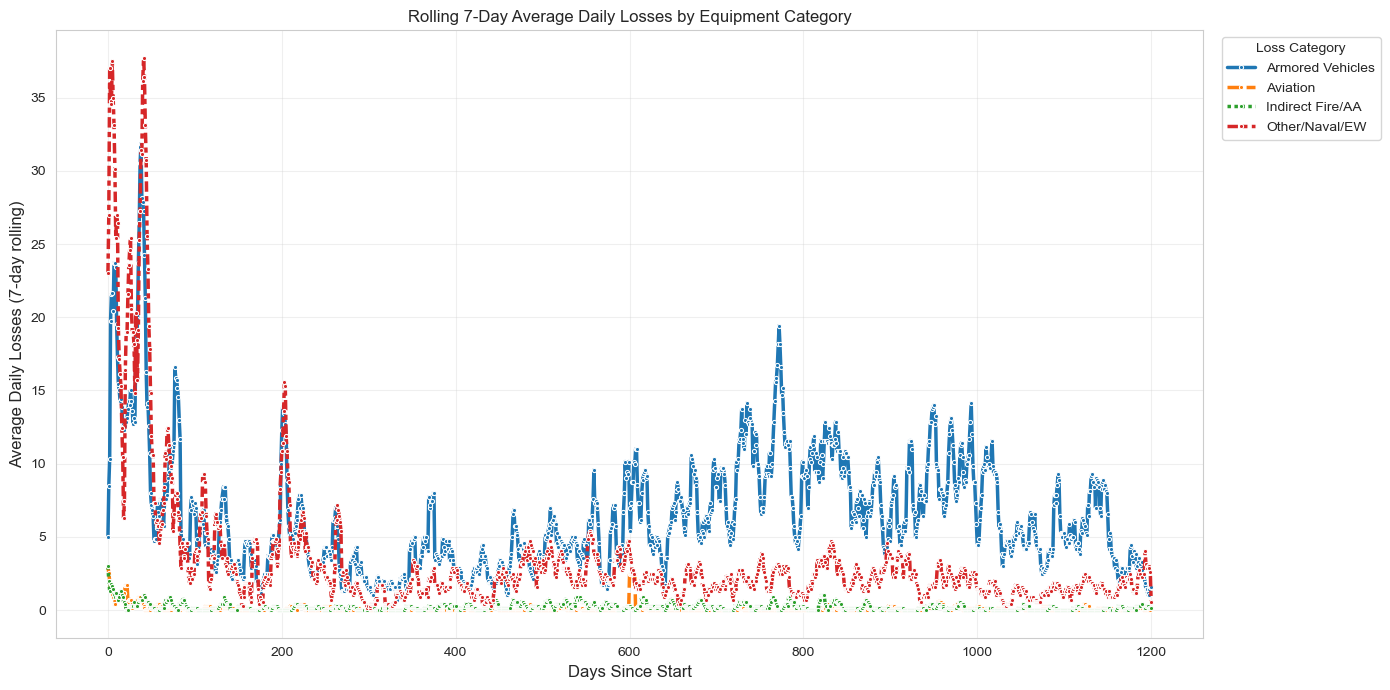

In [33]:
# Aggregate daily losses by loss_category
daily_cat_losses = df_clean.groupby(['days_since_start', 'loss_category'])['loss_count'].sum().unstack(fill_value=0)
# Calculate 7-day rolling mean to smooth the lines
rolling_mean_losses = daily_cat_losses.rolling(window=7, min_periods=1).mean()
# Plot with seaborn
plt.figure(figsize=(14, 7))
sns.lineplot(data=rolling_mean_losses, linewidth=2.5, marker='o', markersize=3)


plt.title('Rolling 7-Day Average Daily Losses by Equipment Category',)
# Labels and styling
plt.xlabel('Days Since Start', fontsize=12)
plt.ylabel('Average Daily Losses (7-day rolling)', fontsize=12)
plt.legend(title='Loss Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

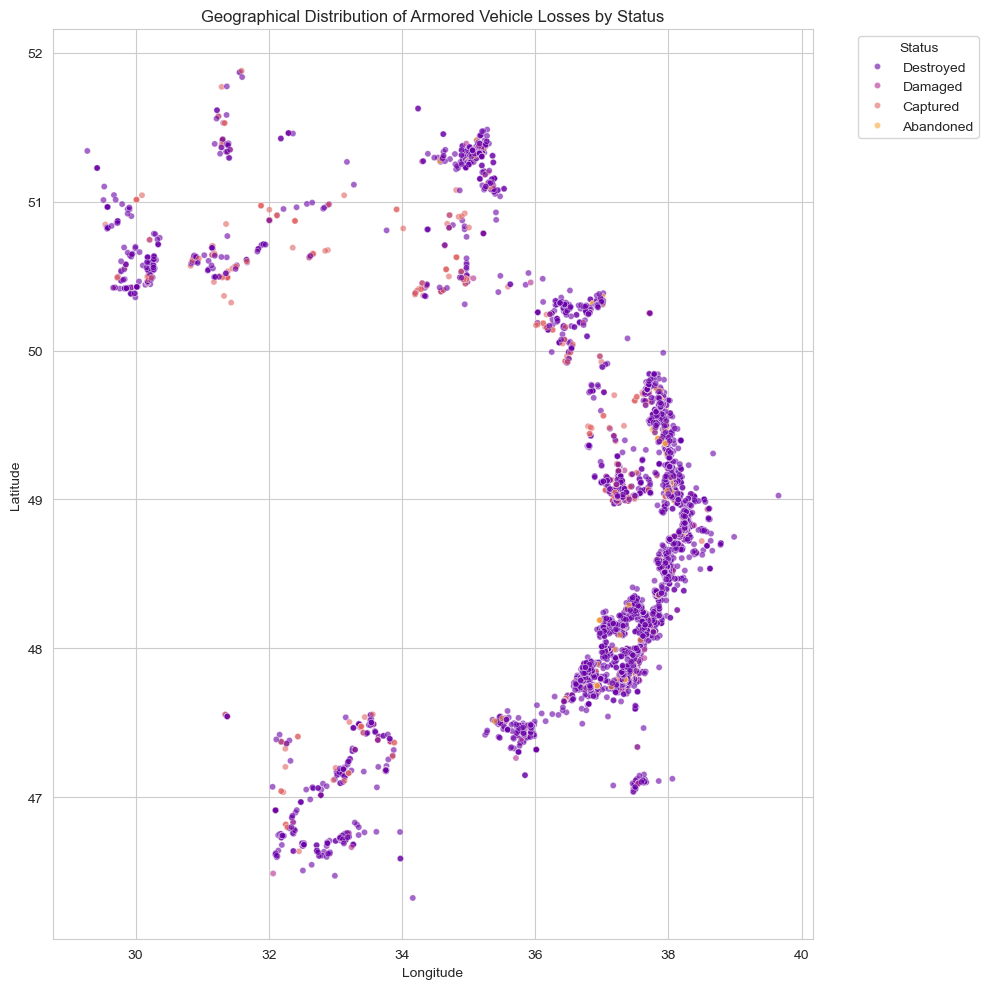

In [60]:
# Geographical Distribution Scatter Plot
# Most common category
armored_losses = df_clean[df_clean['loss_category'] == 'Armored Vehicles']

plt.figure(figsize=(10, 10))
sns.scatterplot(
    x=armored_losses['longitude'], 
    y=armored_losses['latitude'], 
    hue=armored_losses['status'],
    palette='plasma',
    s=20, 
    alpha=0.6
)
plt.title('Geographical Distribution of Armored Vehicle Losses by Status')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

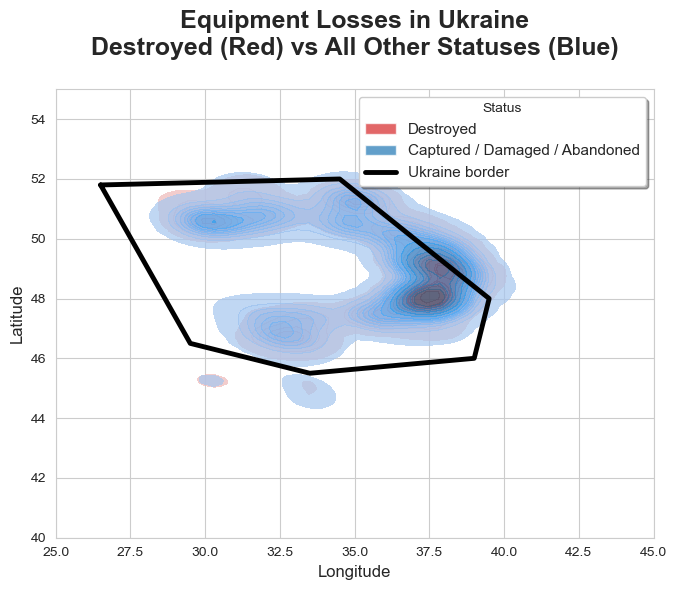

In [40]:
# Filter
relevant_statuses = ['Destroyed', 'Captured', 'Abandoned', 'Damaged',
                     'Damaged and abandoned', 'Damaged and captured']

df_filtered = df_clean[df_clean['status'].isin(relevant_statuses)].copy()

# Create 2 category column
def classify_status(row):
    if 'destroyed' in row['status'].lower():
        return 'Destroyed'
    else:
        return 'Captured / Damaged / Abandoned'

df_filtered['status_group'] = df_filtered.apply(classify_status, axis=1)

# Zoom
NEW_XLIM = (25, 45)
NEW_YLIM = (40, 55)
ukraine_border = np.array([
    [26.5, 51.8], [34.5, 52.0], [39.5, 48.0],
    [39.0, 46.0], [33.5, 45.5], [29.5, 46.5], [26.5, 51.8]
])

# KDE plot
sns.kdeplot(
    data=df_filtered,
    x='longitude', y='latitude',
    hue='status_group',
    fill=True,
    palette={'Destroyed': '#d62728', 
             'Captured / Damaged / Abandoned': '#1f77b4'},
    alpha=0.7,
    levels=15,
    thresh=0.02,
    bw_adjust=0.8,          
    common_norm=False        
)

# Ukraine border
plt.plot(ukraine_border[:, 0], ukraine_border[:, 1],
         color='black', linewidth=3.5, label='Ukraine border')

# Zoom
plt.xlim(NEW_XLIM)
plt.ylim(NEW_YLIM)
plt.title('Equipment Losses in Ukraine\nDestroyed (Red) vs All Other Statuses (Blue)',
          fontsize=18, pad=25, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# legend
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='#d62728', alpha=0.7, label='Destroyed'),
    plt.Rectangle((0,0),1,1, facecolor='#1f77b4', alpha=0.7, label='Captured / Damaged / Abandoned'),
    plt.Line2D([0], [0], color='black', lw=3.5, label='Ukraine border')
]
plt.legend(handles=legend_elements, title='Status', loc='upper right',
           frameon=True, fancybox=True, shadow=True, fontsize=11)

plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

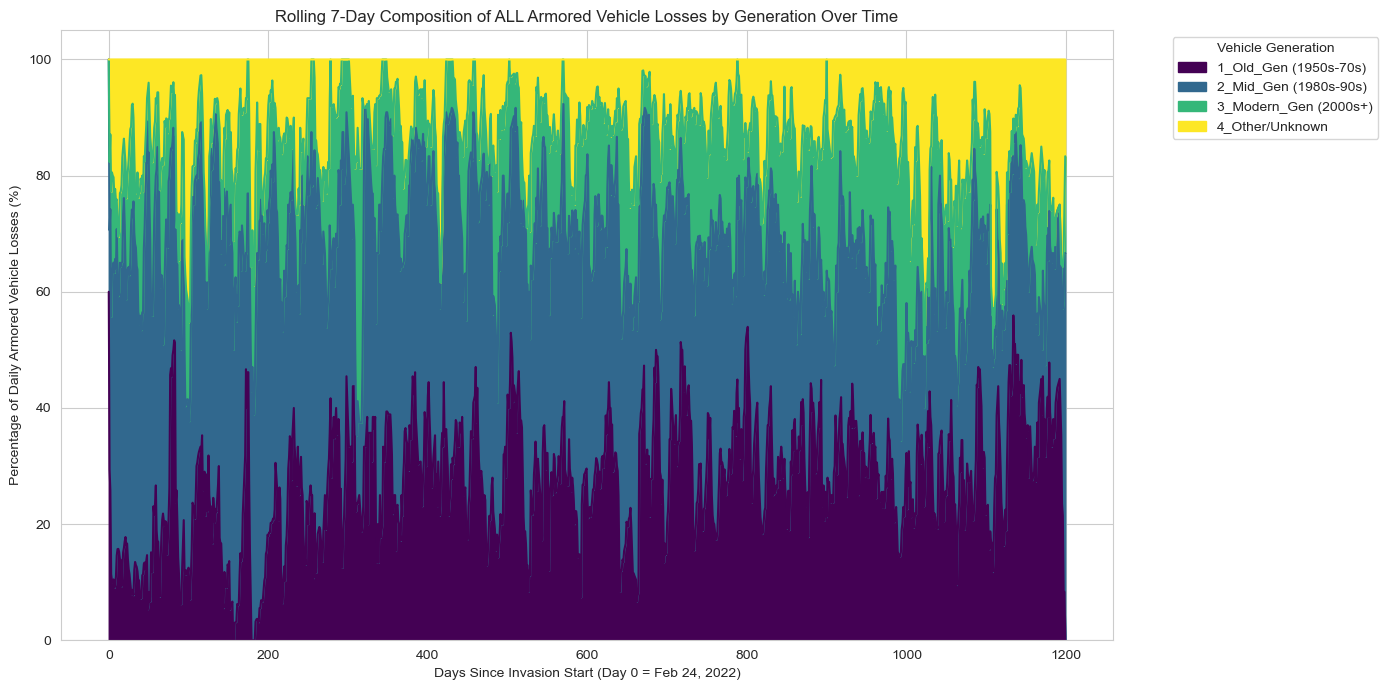

In [30]:
# Filter for armored types and apply classification
armored_types = ['Tanks', 'Armoured Fighting Vehicle', 'Infantry fighting vehicles', 'Armoured Personnel Carrier']
df_armored = df_clean[df_clean['type'].isin(armored_types)].copy()
df_armored['equipment_generation'] = df_armored['model'].apply(classify_full_generation)

# Daily losses by generation and calculate rolling 7-day composition
daily_losses_gen = df_armored.groupby(['days_since_start', 'equipment_generation'])['loss_count'].sum().unstack(fill_value=0)
rolling_losses_gen = daily_losses_gen.rolling(window=7, min_periods=1).mean()
rolling_composition = rolling_losses_gen.div(rolling_losses_gen.sum(axis=1), axis=0) * 100

# Plotting (Stacked Area Plot)
plt.figure(figsize=(14, 7))
# Ordering the columns
plot_columns = ['1_Old_Gen (1950s-70s)', '2_Mid_Gen (1980s-90s)', '3_Modern_Gen (2000s+)', '4_Other/Unknown']

rolling_composition[plot_columns].plot(
    kind='area', 
    stacked=True, 
    ax=plt.gca(),
    cmap='viridis'
)

plt.title('Rolling 7-Day Composition of ALL Armored Vehicle Losses by Generation Over Time')
plt.xlabel('Days Since Invasion Start (Day 0 = Feb 24, 2022)')
plt.ylabel('Percentage of Daily Armored Vehicle Losses (%)')
plt.legend(title='Vehicle Generation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [58]:
!pip install pyarrow

In [59]:
df_clean.to_csv('final_project_tableau_data.tsv', sep='\t', index=False, encoding='utf-8')
print("Data successfully saved as 'final_project_tableau_data.tsv'.")

Data saved as 'final_project_tableau_data.feather'.
